# Examen práctico — Q-Learning tabular con Pac-Man

En este ejercicio trabajaremos con una versión pequeña de Pac-Man diseñada para poder resolverse completamente mediante **Q-Learning tabular**.

La lógica es la misma usada previamente:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

y:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

## Objetivo

Implementar un agente Q-Learning capaz de aprender una política que permita a Pac-Man:

- comer tantas comidas como sea posible;
- evitar al fantasma;
- reducir movimientos innecesarios.

> La implementación del ambiente y la visualización ya están disponibles.  
> La tarea consiste en implementar **el agente y su proceso de aprendizaje**.


## 1. Importaciones y ambiente


In [3]:
import sys
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tabular_pacman_env import (
    TabularPacmanEnv,
    ACTIONS,
)

env = TabularPacmanEnv(seed=7)

print("Número de estados:", env.n_states)
print("Número de acciones:", env.n_actions)


Número de estados: 1944
Número de acciones: 4


## 2. El estado de Pac-Man

Para mantener una Q-table de tamaño manejable utilizaremos la representación:

$$
s=(p,g,n)
$$

donde:

- $p$: posición de Pac-Man;
- $g$: posición del fantasma;
- $n$: número de comidas que permanecen en el tablero.

El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**.

Por tanto:

$$
n_{\text{states}}
=
n_p\,n_g\,(N_{\text{food}}+1).
$$

Esta es una **representación simplificada del estado**: dos configuraciones distintas de comida pueden compartir el mismo $(p,g,n)$.


Estado codificado: 47
Estado decodificado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)


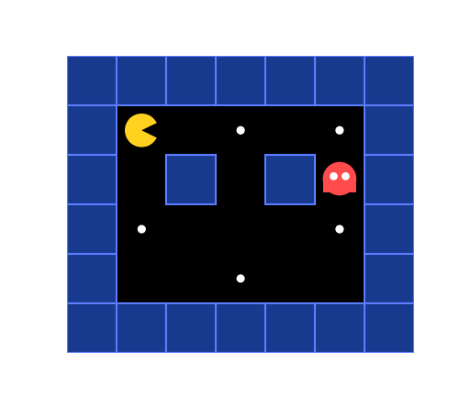

In [5]:
state = env.reset(seed=7)

print("Estado codificado:", state)
print("Estado decodificado:", env.decode_state(state))

frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


### Pregunta 1

Dos tableros pueden tener:

- la misma posición de Pac-Man;
- la misma posición del fantasma;
- el mismo número de comidas restantes;

pero las comidas pueden estar ubicadas en lugares diferentes.

¿Representaría nuestra Q-table ambos tableros como el mismo estado o como estados diferentes? Explique.


### Respuesta #1

Como mencionaes previamente: "El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**."

Esto nos lleva a que la Q-table representaría ambos tableros como el mismo estado, porque solo tiene en cuenta la posición de Pac-Man, la del fantasma y el número de comidas restantes. Como esos tres valores son iguales, ambos tableros corresponden a la misma fila de la tabla.

## 3. Acciones


In [6]:
print(ACTIONS)
print("Acciones legales desde el estado inicial:")
print([ACTIONS[a] for a in env.get_legal_actions()])


{0: 'up', 1: 'right', 2: 'down', 3: 'left'}
Acciones legales desde el estado inicial:
['right', 'down']


Las acciones disponibles son:

| Código | Acción |
|---:|---|
| 0 | arriba |
| 1 | derecha |
| 2 | abajo |
| 3 | izquierda |

El ambiente evita atravesar paredes.


## 4. Observar una transición


In [7]:
state = env.reset(seed=7)

action = env.get_legal_actions()[0]

next_state, reward, done, info = env.step(action)

print("S_t       =", state)
print("A_t       =", ACTIONS[action])
print("R_(t+1)   =", reward)
print("S_(t+1)   =", next_state)
print("done      =", done)
print()
print("S_(t+1) decodificado:")
print(env.decode_state(next_state))


S_t       = 47
A_t       = right
R_(t+1)   = -1
S_(t+1)   = 185
done      = False

S_(t+1) decodificado:
PacmanState(pacman=(1, 2), ghost=(3, 5), food_remaining=5)


La transición observada tiene la forma:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

### Pregunta 2

¿Cuáles de los siguientes valores son entregados directamente por el ambiente y cuáles debe aprender/estimar el agente?

- $R_{t+1}$
- $S_{t+1}$
- $Q(S_t,A_t)$
- $\max_{a'}Q(S_{t+1},a')$


### Respuesta #2

- $R_{t+1}$: lo entrega directamente el ambiente; es la recompensa obtenida al ejecutar la acción.

- $S_{t+1}$: también lo entrega el ambiente; es el estado al que se llega después de actuar.

- $Q(S_t,A_t)$: lo estima y actualiza el agente durante el aprendizaje, usando las recompensas y transiciones que observa.

- $\max_{a'}Q(S_{t+1},a')$: lo calcula el agente buscando el mayor valor estimado en su Q-table para el siguiente estado. No lo entrega el ambiente.


## 5. Q-table


Construya una Q-table inicializada en cero.

Debe tener dimensiones:

$$
n_{\text{states}}\times n_{\text{actions}}.
$$


In [4]:
Q = np.zeros((env.n_states, env.n_actions))


In [5]:
print("Shape esperado:", (env.n_states, env.n_actions))
print("Shape obtenido :", Q.shape)

assert Q.shape == (env.n_states, env.n_actions)
assert np.all(Q == 0)

print("✓ Q-table creada correctamente")


Shape esperado: (1944, 4)
Shape obtenido : (1944, 4)
✓ Q-table creada correctamente


## 6. Política ε-greedy


Implemente:

$$
A_t=
\begin{cases}
\text{acción aleatoria}, & \text{con probabilidad }\epsilon\\[4pt]
\arg\max_a Q(S_t,a), & \text{con probabilidad }1-\epsilon
\end{cases}
$$

Use únicamente las **acciones legales** del estado actual.

Si varias acciones tienen el mismo máximo Q-value, seleccione aleatoriamente entre ellas.


In [6]:
def choose_action(Q, state, epsilon, env):
    legal_actions = env.get_legal_actions()

    # Explorar: elegir una acción legal al azar.
    if random.random() < epsilon:
        return random.choice(legal_actions)

    # Explotar: elegir la acción con mayor Q.
    best_value = max(Q[state, a] for a in legal_actions)

    best_actions = [
        a for a in legal_actions
        if Q[state, a] == best_value
    ]

    return random.choice(best_actions)


### Pregunta 3

Si $\epsilon=0.10$:

1. ¿cuál es la probabilidad de explorar?
2. ¿cuál es la probabilidad de explotar?
3. ¿qué ocurre cuando todos los Q-values iniciales son iguales?


### Respuesta #3

1. La probabilidad de explorar es del 10 %: el agente elige una acción legal al azar.

2. La probabilidad de explotar es del 90 %: elige una de las acciones legales con mayor Q-value.

3. Cuando todos los Q-values iniciales son iguales, todas las acciones legales empatan. Como los empates se resuelven al azar, el agente termina eligiendo aleatoriamente incluso cuando explota.


## 7. Actualización Q-Learning


Para cada transición utilice:

$$
\text{TD target}
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

$$
\text{TD error}
=
\text{TD target}
-
Q(S_t,A_t)
$$

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha(\text{TD error})
$$

Cuando $S_{t+1}$ sea terminal:

$$
\max_{a'}Q(S_{t+1},a')=0.
$$


In [7]:
def update_q(
    Q,
    state,
    action,
    reward,
    next_state,
    done,
    alpha,
    gamma,
):
    if done:
        td_target = reward
    else:
        td_target = reward + gamma * np.max(Q[next_state])

    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error

    return td_target, td_error


### Prueba manual de la actualización


In [8]:
# Esta celda NO entrena al agente.
# Solo permite revisar una actualización controlada.

Q_test = np.zeros((env.n_states, env.n_actions))

s = env.reset(seed=7)
a = env.get_legal_actions()[0]

s_next, r, done, _ = env.step(a)

# Valor ficticio conocido para verificar el cálculo.
if not done:
    Q_test[s_next, 1] = 4.0

td_target, td_error = update_q(
    Q_test,
    state=s,
    action=a,
    reward=r,
    next_state=s_next,
    done=done,
    alpha=0.5,
    gamma=0.9,
)

print("TD target:", td_target)
print("TD error :", td_error)
print("Nuevo Q  :", Q_test[s, a])


TD target: 2.6
TD error : 2.6
Nuevo Q  : 1.3


### Pregunta 4

Explique con sus palabras la diferencia entre:

- **TD target**
- **TD error**
- **nuevo Q-value**


### Respuesta #4

TD target: es el valor que usamos como referencia para mejorar lo que el agente sabe.

TD error: es la diferencia entre esa referencia y lo que el agente estimaba antes.

Nuevo Q-value: es la estimación corregida. El agente ajusta el valor anterior usando una parte del error, según alpha.

## 8. Entrenamiento


Implemente el ciclo completo de entrenamiento:

1. reiniciar el ambiente;
2. seleccionar una acción con $\epsilon$-greedy;
3. ejecutar la acción;
4. observar $R_{t+1}$ y $S_{t+1}$;
5. actualizar $Q(S_t,A_t)$;
6. avanzar al nuevo estado;
7. terminar cuando `done=True`.

Guarde la recompensa total obtenida en cada episodio.


In [9]:
def train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
):
    Q = np.zeros((env.n_states, env.n_actions))
    random.seed(seed)

    episode_rewards = []
    episode_lengths = []
    wins = []

    for episode in range(episodes):
        state = env.reset(seed=seed + episode)

        total_reward = 0
        steps = 0

        for _ in range(max_steps):
            # Elegir una acción e interactuar con el ambiente.
            action = choose_action(Q, state, epsilon, env)
            next_state, reward, done, info = env.step(action)

            # Actualizar lo aprendido.
            update_q(
                Q, state, action, reward,
                next_state, done, alpha, gamma
            )

            state = next_state
            total_reward += reward
            steps += 1

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        wins.append(int(info.get("won", False)))

    return Q, episode_rewards, episode_lengths, wins


## 9. Entrenar


In [10]:
Q, rewards, lengths, wins = train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
)

print("Entrenamiento terminado")
print("Q-table:", Q.shape)


Entrenamiento terminado
Q-table: (1944, 4)


## 10. Curva de aprendizaje


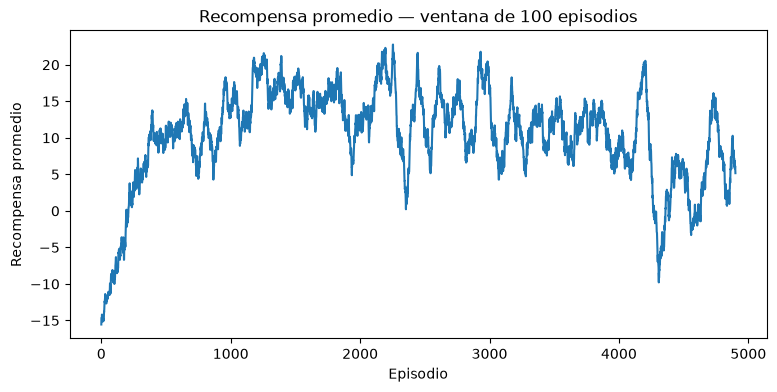

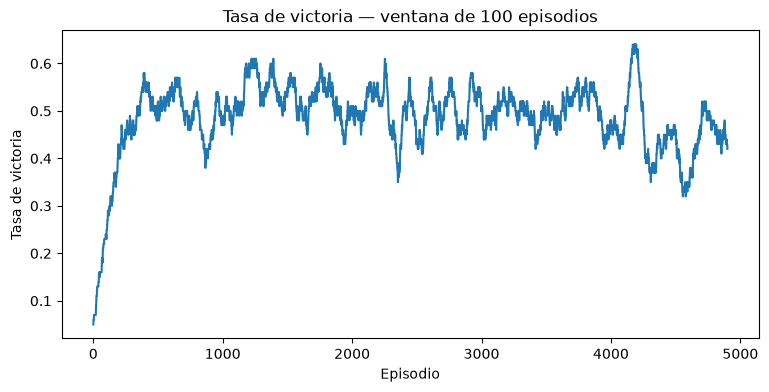

In [11]:
window = 100

moving_reward = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid",
)

moving_win_rate = np.convolve(
    wins,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(9, 4))
plt.plot(moving_reward)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Recompensa promedio — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(moving_win_rate)
plt.xlabel("Episodio")
plt.ylabel("Tasa de victoria")
plt.title(f"Tasa de victoria — ventana de {window} episodios")
plt.show()


### Pregunta 5

A partir de las curvas:

1. ¿hay evidencia de aprendizaje?
2. ¿qué ocurre con la recompensa promedio?
3. ¿qué ocurre con la tasa de victoria?


### Respuesta #5

1. Sí hay aprendizaje, porque al inicio el agente obtiene recompensas negativas y gana pocas veces. Después de varios cientos de episodios, ambas medidas mejoran.

2. La recompensa promedio pasa de aproximadamente −15 a valores positivos, con picos por encima de 20. Sin embargo, sigue subiendo y bajando, y al final es menor que en varios momentos anteriores.

3. La tasa de victoria empieza cerca del 5 % y después se mueve principalmente entre el 40 % y el 60 %. El agente logra ganar más que al principio, pero no muestra una mejora continua ni llega a ganar siempre.

## 11. Política aprendida


In [12]:
state = env.reset(seed=7)
decoded = env.decode_state(state)

print("Estado:", decoded)
print()

legal_actions = env.get_legal_actions()

for action in legal_actions:
    print(
        f"{ACTIONS[action]:>8} : "
        f"Q = {Q[state, action]:.3f}"
    )

best_value = max(Q[state, a] for a in legal_actions)

best_actions = [
    a for a in legal_actions
    if Q[state, a] == best_value
]

print()
print("Mejor(es) acción(es):", [ACTIONS[a] for a in best_actions])


Estado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)

   right : Q = 21.821
    down : Q = 17.989

Mejor(es) acción(es): ['right']


### Pregunta 6

Interprete los Q-values del estado inicial.

¿Qué acción prefiere el agente y qué significa que una acción tenga un Q-value mayor que otra?


### Respuesta #6

El agente prefiere moverse a la derecha porque su Q-value es mayor que el de bajar. Según lo aprendido durante el entrenamiento, estima que empezar por la derecha le dará una mayor recompensa acumulada.


## 12. Reproducir un episodio


In [13]:
def greedy_action(Q, state, env):
    legal_actions = env.get_legal_actions()

    values = np.array([
        Q[state, action]
        for action in legal_actions
    ])

    best_value = np.max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return random.choice(best_actions)


def play_episode(
    env,
    Q=None,
    random_policy=False,
    seed=20,
    max_steps=100,
):
    state = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):

        if random_policy:
            action = random.choice(env.get_legal_actions())
        else:
            action = greedy_action(Q, state, env)

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        state = next_state
        frames.append(env.render())

        if done:
            break

    return frames, total_reward, step + 1, info


def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


### Política aleatoria


In [14]:
frames_random, reward_random, steps_random, info_random = play_episode(
    env,
    random_policy=True,
    seed=20,
)

print("Reward:", reward_random)
print("Pasos :", steps_random)
print("Comió :", info_random["food_eaten"], "de", env.max_food)
print("Ganó  :", info_random["won"])

frames_to_video(frames_random)


Reward: -24
Pasos : 17
Comió : 2 de 5
Ganó  : False


### Política aprendida


In [15]:
frames_trained, reward_trained, steps_trained, info_trained = play_episode(
    env,
    Q=Q,
    random_policy=False,
    seed=20,
)

print("Reward:", reward_trained)
print("Pasos :", steps_trained)
print("Comió :", info_trained["food_eaten"], "de", env.max_food)
print("Ganó  :", info_trained["won"])

frames_to_video(frames_trained)


Reward: 55
Pasos : 20
Comió : 5 de 5
Ganó  : True


### Pregunta 7

Compare el episodio aleatorio con el episodio del agente entrenado.

Discuta:

- cantidad de movimientos;
- recompensa total;
- cantidad de comidas recolectadas;
- comportamiento frente al fantasma.

Explique por qué la recompensa acumulada favorece simultáneamente **comer**, **usar menos pasos** y **evitar morir**.


### Respuesta #7

La política aleatoria hizo 17 movimientos, comió 2 de las 5 comidas y terminó atrapada por el fantasma, con una recompensa de −24. La política aprendida hizo 20 movimientos, recogió las 5 comidas y ganó, con una recompensa de 55.

Aunque el agente entrenado dio más pasos, los aprovechó mejor y logró completar el objetivo sin ser atrapado. Hacer menos movimientos no significa jugar mejor si el episodio termina antes porque el agente muere.

La recompensa favorece recoger comida porque da +10 por cada comida y +30 por la última. También favorece evitar movimientos innecesarios, porque un paso sin comer da −1, y evitar al fantasma, porque ser atrapado da −30.


## 13. Evaluación final


In [16]:
def evaluate_policy(
    env,
    Q,
    episodes=200,
    max_steps=100,
):
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=10000 + episode)
        total_reward = 0

        for step in range(max_steps):

            action = greedy_action(Q, state, env)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return {
        "reward_promedio": np.mean(rewards),
        "pasos_promedio": np.mean(lengths),
        "tasa_victoria": np.mean(wins),
    }


results = evaluate_policy(env, Q)
results


{'reward_promedio': np.float64(13.91),
 'pasos_promedio': np.float64(51.98),
 'tasa_victoria': np.float64(0.715)}

## Entrega

El notebook debe ejecutar completamente y contener:

1. Q-table correctamente inicializada;
2. política $\epsilon$-greedy;
3. actualización de Q-Learning;
4. ciclo de entrenamiento;
5. curva de aprendizaje;
6. interpretación de resultados;
7. comparación entre política aleatoria y política aprendida.

No se requiere modificar el código del ambiente.
